# Insurance Data - Complete Preprocessing, EDA, and Visualization

This notebook provides a comprehensive analysis of the insurance dataset including:
- Data Loading and Exploration
- Data Cleaning and Preprocessing
- Exploratory Data Analysis (EDA)
- Advanced Visualizations

## 1. Import Required Libraries

In [7]:
# Import essential libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# For preprocessing
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.impute import SimpleImputer

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("All libraries imported successfully!")

All libraries imported successfully!


## 2. Load and Explore Dataset

In [8]:
# Load the dataset
df = pd.read_csv('insurance.csv')

# Display basic information
print("=" * 80)
print("DATASET SHAPE")
print("=" * 80)
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
print(f"\nTotal Records: {df.shape[0]}")

print("\n" + "=" * 80)
print("FIRST FEW ROWS")
print("=" * 80)
print(df.head(10))

print("\n" + "=" * 80)
print("DATASET INFORMATION")
print("=" * 80)
print(df.info())

print("\n" + "=" * 80)
print("COLUMN NAMES AND DATA TYPES")
print("=" * 80)
print(df.dtypes)

print("\n" + "=" * 80)
print("STATISTICAL SUMMARY")
print("=" * 80)
print(df.describe())

DATASET SHAPE
Rows: 1338, Columns: 7

Total Records: 1338

FIRST FEW ROWS
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520
5   31  female  25.740         0     no  southeast   3756.62160
6   46  female  33.440         1     no  southeast   8240.58960
7   37  female  27.740         3     no  northwest   7281.50560
8   37    male  29.830         2     no  northeast   6406.41070
9   60  female  25.840         0     no  northwest  28923.13692

DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       13

## 3. Data Cleaning - Missing Values Analysis

MISSING VALUES ANALYSIS
            Column  Missing_Count  Missing_Percentage
age            age              0                 0.0
sex            sex              0                 0.0
bmi            bmi              0                 0.0
children  children              0                 0.0
smoker      smoker              0                 0.0
region      region              0                 0.0
charges    charges              0                 0.0

✓ No missing values found in the dataset!

DUPLICATE RECORDS ANALYSIS
Total Duplicate Rows: 1
Removing duplicates...
Dataset shape after removing duplicates: (1337, 7)


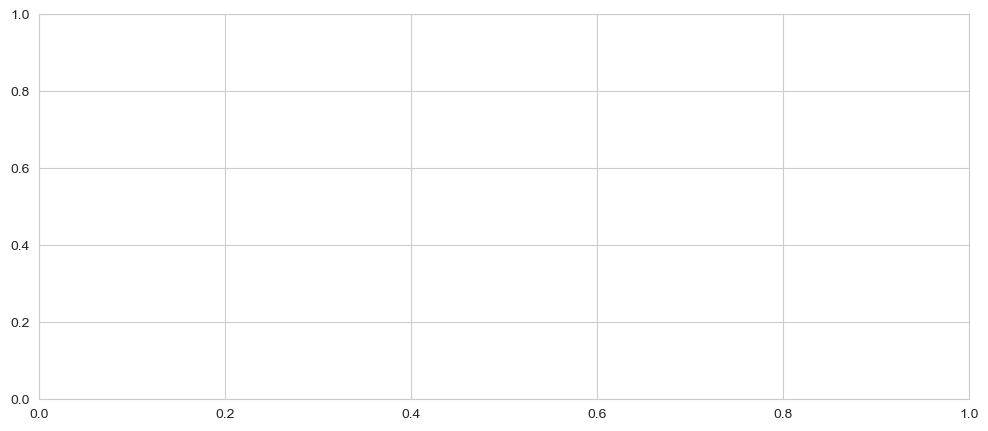

In [9]:
# Check for missing values
print("=" * 80)
print("MISSING VALUES ANALYSIS")
print("=" * 80)
missing_data = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df)) * 100
})
print(missing_data)

# Visualize missing values
fig, ax = plt.subplots(figsize=(12, 5))
missing_data_plot = df.isnull().sum()
missing_data_plot = missing_data_plot[missing_data_plot > 0]

if len(missing_data_plot) > 0:
    missing_data_plot.plot(kind='bar', ax=ax, color='coral')
    plt.title('Missing Values Count by Column', fontsize=14, fontweight='bold')
    plt.ylabel('Count of Missing Values')
    plt.xlabel('Columns')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("\n✓ No missing values found in the dataset!")

# Check for duplicates
print("\n" + "=" * 80)
print("DUPLICATE RECORDS ANALYSIS")
print("=" * 80)
duplicate_count = df.duplicated().sum()
print(f"Total Duplicate Rows: {duplicate_count}")
if duplicate_count > 0:
    print("Removing duplicates...")
    df = df.drop_duplicates()
    print(f"Dataset shape after removing duplicates: {df.shape}")

## 4. Data Type Conversion and Validation

In [10]:
# Convert categorical columns to appropriate types
print("=" * 80)
print("DATA TYPE CONVERSION")
print("=" * 80)

# Identify categorical and numerical columns
categorical_cols = ['sex', 'smoker', 'region']
numerical_cols = ['age', 'bmi', 'children', 'charges']

print(f"\nCategorical Columns: {categorical_cols}")
print(f"Numerical Columns: {numerical_cols}")

# Validate data consistency
print("\n" + "=" * 80)
print("DATA VALIDATION - UNIQUE VALUES")
print("=" * 80)

for col in categorical_cols:
    unique_vals = df[col].unique()
    print(f"\n{col}: {unique_vals} (Count: {df[col].nunique()})")

# Check for invalid values in numerical columns
print("\n" + "=" * 80)
print("NUMERICAL COLUMNS SUMMARY")
print("=" * 80)
for col in numerical_cols:
    print(f"\n{col}:")
    print(f"  Min: {df[col].min()}, Max: {df[col].max()}")
    print(f"  Mean: {df[col].mean():.2f}, Median: {df[col].median():.2f}")
    print(f"  Std Dev: {df[col].std():.2f}")

# Create a copy for preprocessing
df_processed = df.copy()

DATA TYPE CONVERSION

Categorical Columns: ['sex', 'smoker', 'region']
Numerical Columns: ['age', 'bmi', 'children', 'charges']

DATA VALIDATION - UNIQUE VALUES

sex: ['female' 'male'] (Count: 2)

smoker: ['yes' 'no'] (Count: 2)

region: ['southwest' 'southeast' 'northwest' 'northeast'] (Count: 4)

NUMERICAL COLUMNS SUMMARY

age:
  Min: 18, Max: 64
  Mean: 39.22, Median: 39.00
  Std Dev: 14.04

bmi:
  Min: 15.96, Max: 53.13
  Mean: 30.66, Median: 30.40
  Std Dev: 6.10

children:
  Min: 0, Max: 5
  Mean: 1.10, Median: 1.00
  Std Dev: 1.21

charges:
  Min: 1121.8739, Max: 63770.42801
  Mean: 13279.12, Median: 9386.16
  Std Dev: 12110.36


## 5. Outlier Detection and Treatment

OUTLIER DETECTION (IQR METHOD)

age:
  Outliers Detected: 0 (0.00%)

bmi:
  Outliers Detected: 9 (0.67%)

children:
  Outliers Detected: 0 (0.00%)

charges:
  Outliers Detected: 139 (10.40%)


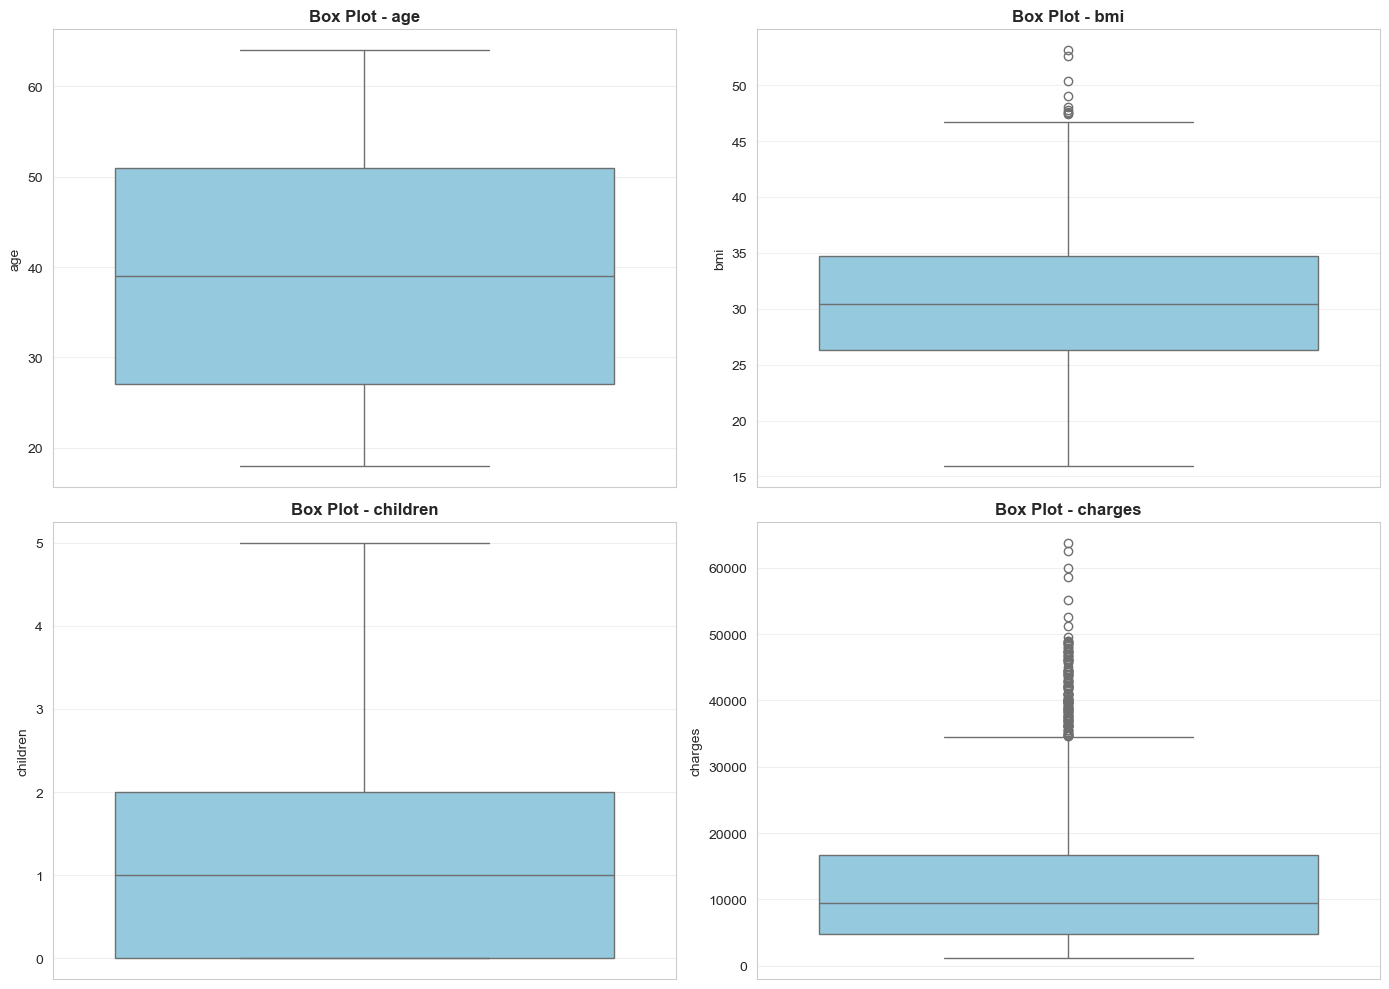


OUTLIER DETECTION (Z-SCORE METHOD - |Z| > 3)
age: 0 outliers
bmi: 4 outliers
children: 18 outliers
charges: 7 outliers


In [11]:
# Outlier Detection using IQR method
print("=" * 80)
print("OUTLIER DETECTION (IQR METHOD)")
print("=" * 80)

def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return (data[column] < lower_bound) | (data[column] > upper_bound)

# Detect outliers for numerical columns
outliers_dict = {}
for col in numerical_cols:
    outliers = detect_outliers_iqr(df, col)
    outliers_dict[col] = outliers.sum()
    print(f"\n{col}:")
    print(f"  Outliers Detected: {outliers.sum()} ({(outliers.sum()/len(df)*100):.2f}%)")

# Visualize outliers with box plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for idx, col in enumerate(numerical_cols):
    sns.boxplot(data=df, y=col, ax=axes[idx], color='skyblue')
    axes[idx].set_title(f'Box Plot - {col}', fontweight='bold')
    axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Also show using Z-score method
print("\n" + "=" * 80)
print("OUTLIER DETECTION (Z-SCORE METHOD - |Z| > 3)")
print("=" * 80)

from scipy import stats

for col in numerical_cols:
    z_scores = np.abs(stats.zscore(df[col]))
    z_outliers = (z_scores > 3).sum()
    print(f"{col}: {z_outliers} outliers")

## 6. Feature Scaling and Normalization

FEATURE SCALING TECHNIQUES

Original Data (Sample):
   age    bmi  children     charges
0   19  27.90         0  16884.9240
1   18  33.77         1   1725.5523
2   28  33.00         3   4449.4620

--------------------------------------------------------------------------------
StandardScaler (Mean=0, Std=1):
        age       bmi  children   charges
0 -1.440418 -0.453160 -0.909234  0.297857
1 -1.511647  0.509422 -0.079442 -0.954381
2 -0.799350  0.383155  1.580143 -0.729373
Mean: [-6.64306971e-17 -2.28521598e-16  3.85298043e-17 -1.00974660e-16]
Std: [1.00037418 1.00037418 1.00037418 1.00037418]

--------------------------------------------------------------------------------
MinMaxScaler (Range 0-1):
        age       bmi  children   charges
0  0.021739  0.321227       0.0  0.251611
1  0.000000  0.479150       0.2  0.009636
2  0.217391  0.458434       0.6  0.053115
Min: [0. 0. 0. 0.]
Max: [1. 1. 1. 1.]


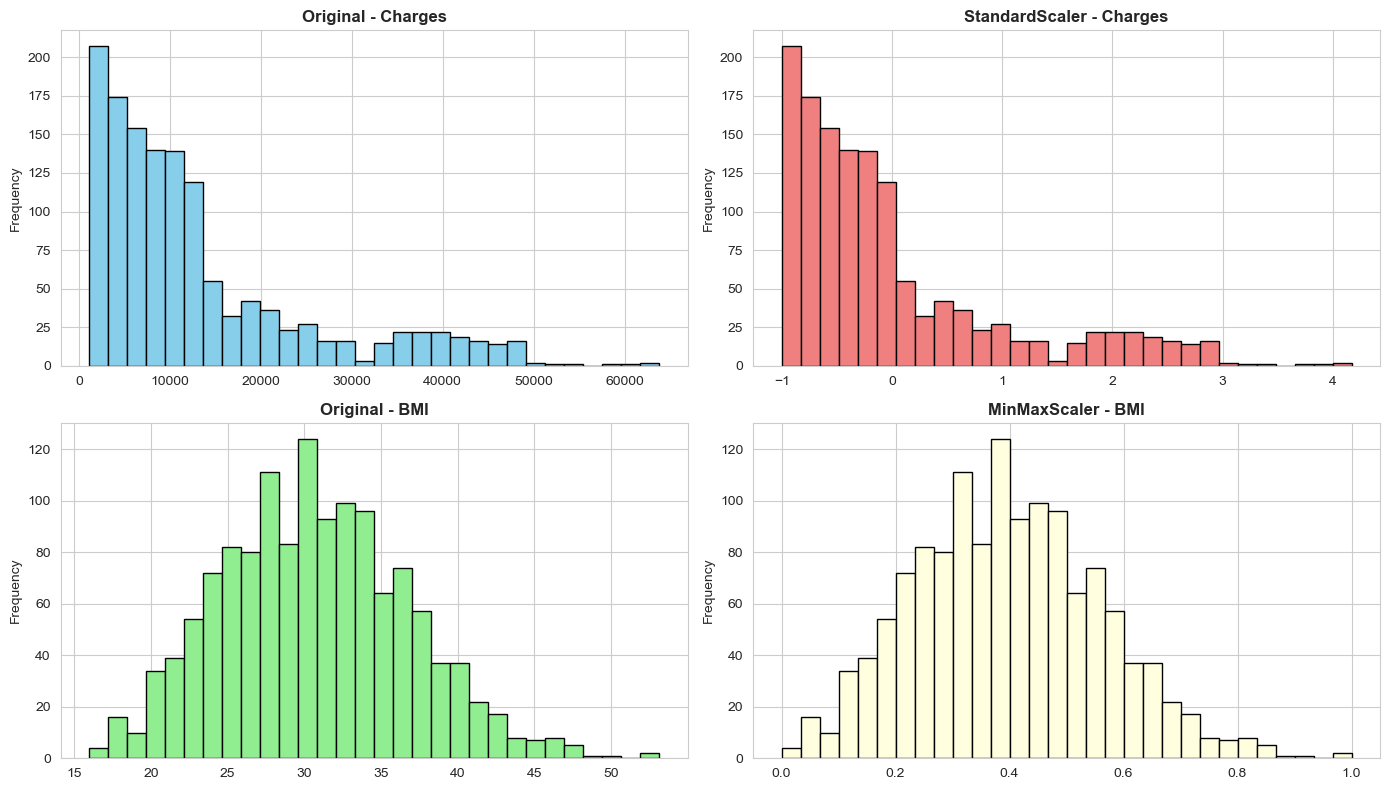


✓ Scaling complete!


In [12]:
# Feature Scaling Comparison
print("=" * 80)
print("FEATURE SCALING TECHNIQUES")
print("=" * 80)

# Create copies for different scaling methods
df_standard = df_processed.copy()
df_minmax = df_processed.copy()

# StandardScaler (Z-score normalization)
scaler_standard = StandardScaler()
df_standard[numerical_cols] = scaler_standard.fit_transform(df_processed[numerical_cols])

# MinMaxScaler (0-1 normalization)
scaler_minmax = MinMaxScaler()
df_minmax[numerical_cols] = scaler_minmax.fit_transform(df_processed[numerical_cols])

print("\nOriginal Data (Sample):")
print(df_processed[numerical_cols].head(3))

print("\n" + "-" * 80)
print("StandardScaler (Mean=0, Std=1):")
print(df_standard[numerical_cols].head(3))
print(f"Mean: {df_standard[numerical_cols].mean().values}")
print(f"Std: {df_standard[numerical_cols].std().values}")

print("\n" + "-" * 80)
print("MinMaxScaler (Range 0-1):")
print(df_minmax[numerical_cols].head(3))
print(f"Min: {df_minmax[numerical_cols].min().values}")
print(f"Max: {df_minmax[numerical_cols].max().values}")

# Visualize scaling before and after
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Original
axes[0, 0].hist(df_processed['charges'], bins=30, color='skyblue', edgecolor='black')
axes[0, 0].set_title('Original - Charges', fontweight='bold')
axes[0, 0].set_ylabel('Frequency')

# StandardScaler
axes[0, 1].hist(df_standard['charges'], bins=30, color='lightcoral', edgecolor='black')
axes[0, 1].set_title('StandardScaler - Charges', fontweight='bold')
axes[0, 1].set_ylabel('Frequency')

# Original BMI
axes[1, 0].hist(df_processed['bmi'], bins=30, color='lightgreen', edgecolor='black')
axes[1, 0].set_title('Original - BMI', fontweight='bold')
axes[1, 0].set_ylabel('Frequency')

# MinMaxScaler BMI
axes[1, 1].hist(df_minmax['bmi'], bins=30, color='lightyellow', edgecolor='black')
axes[1, 1].set_title('MinMaxScaler - BMI', fontweight='bold')
axes[1, 1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print("\n✓ Scaling complete!")

## 7. Univariate Analysis - Individual Feature Distributions

UNIVARIATE ANALYSIS - NUMERICAL FEATURES


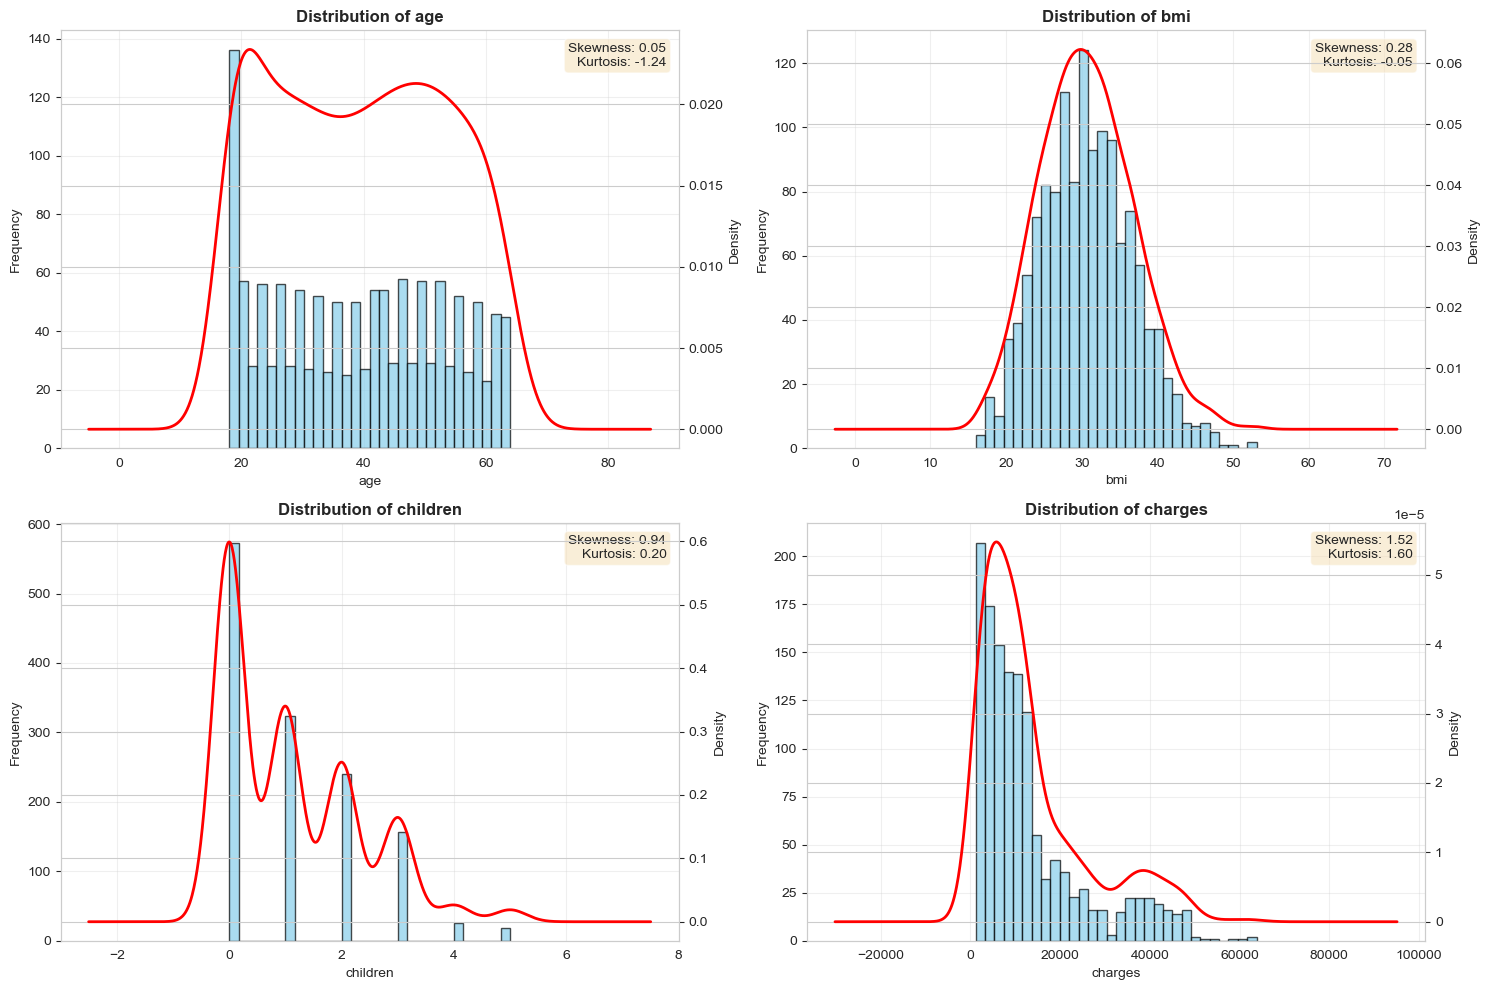


STATISTICAL SUMMARY FOR NUMERICAL FEATURES

age:
  Count: 1337
  Mean: 39.22
  Median: 39.00
  Std Dev: 14.04
  Variance: 197.24
  Min: 18.00
  Max: 64.00
  Q1 (25%): 27.00
  Q3 (75%): 51.00
  IQR: 24.00
  Skewness: 0.05
  Kurtosis: -1.24

bmi:
  Count: 1337
  Mean: 30.66
  Median: 30.40
  Std Dev: 6.10
  Variance: 37.22
  Min: 15.96
  Max: 53.13
  Q1 (25%): 26.29
  Q3 (75%): 34.70
  IQR: 8.41
  Skewness: 0.28
  Kurtosis: -0.05

children:
  Count: 1337
  Mean: 1.10
  Median: 1.00
  Std Dev: 1.21
  Variance: 1.45
  Min: 0.00
  Max: 5.00
  Q1 (25%): 0.00
  Q3 (75%): 2.00
  IQR: 2.00
  Skewness: 0.94
  Kurtosis: 0.20

charges:
  Count: 1337
  Mean: 13279.12
  Median: 9386.16
  Std Dev: 12110.36
  Variance: 146660811.01
  Min: 1121.87
  Max: 63770.43
  Q1 (25%): 4746.34
  Q3 (75%): 16657.72
  IQR: 11911.37
  Skewness: 1.52
  Kurtosis: 1.60


In [13]:
# Univariate Analysis - Numerical Features
print("=" * 80)
print("UNIVARIATE ANALYSIS - NUMERICAL FEATURES")
print("=" * 80)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.ravel()

for idx, col in enumerate(numerical_cols):
    # Histogram with KDE
    axes[idx].hist(df[col], bins=30, color='skyblue', alpha=0.7, edgecolor='black', label='Histogram')
    ax2 = axes[idx].twinx()
    df[col].plot(kind='density', color='red', linewidth=2, ax=ax2, label='Density')
    
    axes[idx].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')
    axes[idx].grid(alpha=0.3)
    
    # Add statistics
    skewness = df[col].skew()
    kurtosis = df[col].kurtosis()
    axes[idx].text(0.98, 0.97, f'Skewness: {skewness:.2f}\nKurtosis: {kurtosis:.2f}', 
                   transform=axes[idx].transAxes, verticalalignment='top', 
                   horizontalalignment='right', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

# Statistical Summary for each numerical column
print("\n" + "=" * 80)
print("STATISTICAL SUMMARY FOR NUMERICAL FEATURES")
print("=" * 80)

for col in numerical_cols:
    print(f"\n{col}:")
    print(f"  Count: {df[col].count()}")
    print(f"  Mean: {df[col].mean():.2f}")
    print(f"  Median: {df[col].median():.2f}")
    print(f"  Std Dev: {df[col].std():.2f}")
    print(f"  Variance: {df[col].var():.2f}")
    print(f"  Min: {df[col].min():.2f}")
    print(f"  Max: {df[col].max():.2f}")
    print(f"  Q1 (25%): {df[col].quantile(0.25):.2f}")
    print(f"  Q3 (75%): {df[col].quantile(0.75):.2f}")
    print(f"  IQR: {df[col].quantile(0.75) - df[col].quantile(0.25):.2f}")
    print(f"  Skewness: {df[col].skew():.2f}")
    print(f"  Kurtosis: {df[col].kurtosis():.2f}")

## 8. Bivariate Analysis - Relationships Between Variables

CORRELATION MATRIX - NUMERICAL FEATURES

Correlation Matrix:
               age       bmi  children   charges
age       1.000000  0.109344  0.041536  0.298308
bmi       0.109344  1.000000  0.012755  0.198401
children  0.041536  0.012755  1.000000  0.067389
charges   0.298308  0.198401  0.067389  1.000000


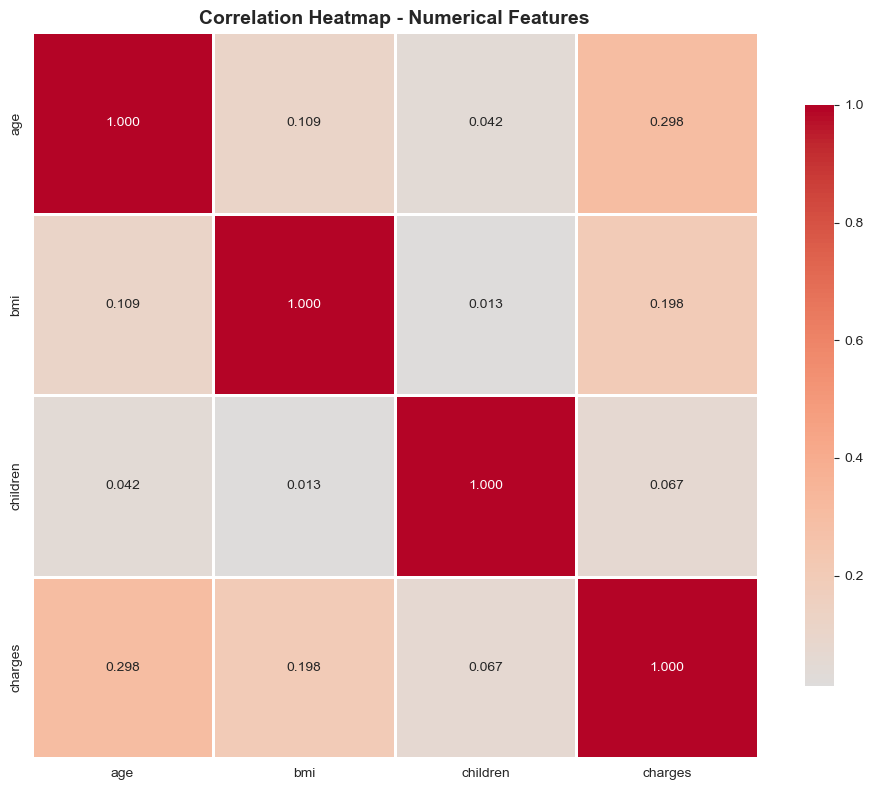


SCATTER PLOTS - RELATIONSHIPS WITH TARGET (CHARGES)


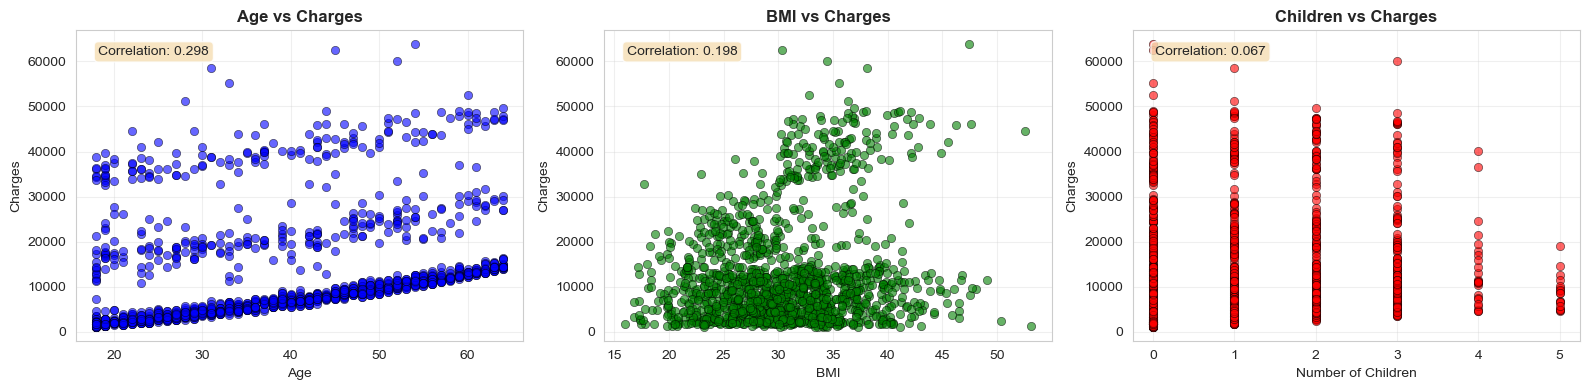

In [14]:
# Correlation Analysis
print("=" * 80)
print("CORRELATION MATRIX - NUMERICAL FEATURES")
print("=" * 80)

# Calculate correlation matrix
correlation_matrix = df[numerical_cols].corr()
print("\nCorrelation Matrix:")
print(correlation_matrix)

# Visualize correlation heatmap
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title('Correlation Heatmap - Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Scatter plots - Relationships with target variable (charges)
print("\n" + "=" * 80)
print("SCATTER PLOTS - RELATIONSHIPS WITH TARGET (CHARGES)")
print("=" * 80)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Age vs Charges
axes[0].scatter(df['age'], df['charges'], alpha=0.6, color='blue', edgecolors='black', linewidth=0.5)
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Charges')
axes[0].set_title('Age vs Charges', fontweight='bold')
corr_age = df['age'].corr(df['charges'])
axes[0].text(0.05, 0.95, f'Correlation: {corr_age:.3f}', transform=axes[0].transAxes, 
             verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
axes[0].grid(alpha=0.3)

# BMI vs Charges
axes[1].scatter(df['bmi'], df['charges'], alpha=0.6, color='green', edgecolors='black', linewidth=0.5)
axes[1].set_xlabel('BMI')
axes[1].set_ylabel('Charges')
axes[1].set_title('BMI vs Charges', fontweight='bold')
corr_bmi = df['bmi'].corr(df['charges'])
axes[1].text(0.05, 0.95, f'Correlation: {corr_bmi:.3f}', transform=axes[1].transAxes, 
             verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
axes[1].grid(alpha=0.3)

# Children vs Charges
axes[2].scatter(df['children'], df['charges'], alpha=0.6, color='red', edgecolors='black', linewidth=0.5)
axes[2].set_xlabel('Number of Children')
axes[2].set_ylabel('Charges')
axes[2].set_title('Children vs Charges', fontweight='bold')
corr_children = df['children'].corr(df['charges'])
axes[2].text(0.05, 0.95, f'Correlation: {corr_children:.3f}', transform=axes[2].transAxes, 
             verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Categorical Data Analysis

CATEGORICAL VARIABLES DISTRIBUTION

sex:
sex
male      675
female    662
Name: count, dtype: int64
Value Percentages:
sex
male      50.486163
female    49.513837
Name: proportion, dtype: float64

smoker:
smoker
no     1063
yes     274
Name: count, dtype: int64
Value Percentages:
smoker
no     79.506358
yes    20.493642
Name: proportion, dtype: float64

region:
region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64
Value Percentages:
region
southeast    27.225131
southwest    24.308153
northwest    24.233358
northeast    24.233358
Name: proportion, dtype: float64


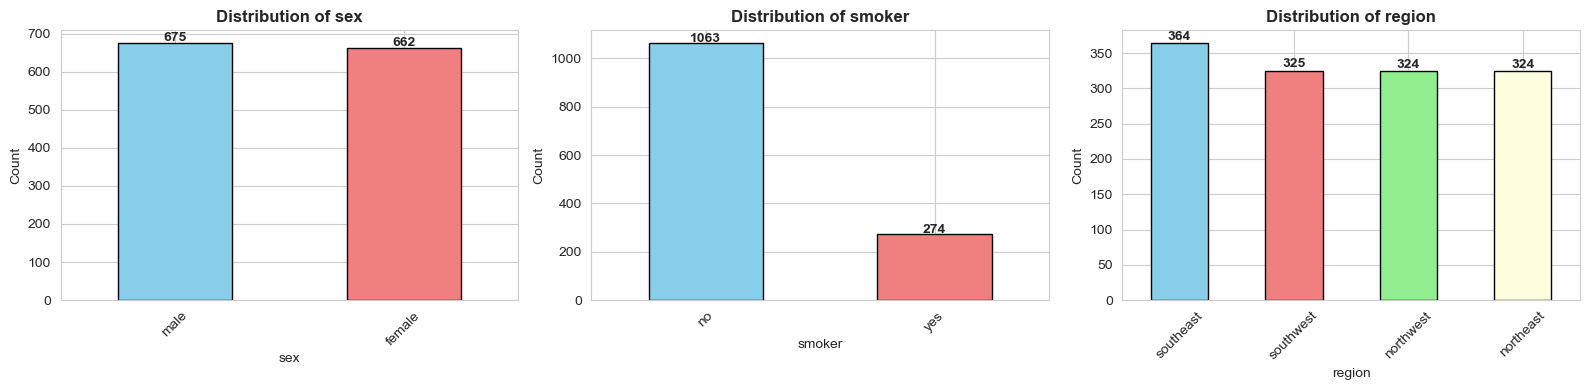


CATEGORICAL FEATURES vs TARGET (CHARGES)


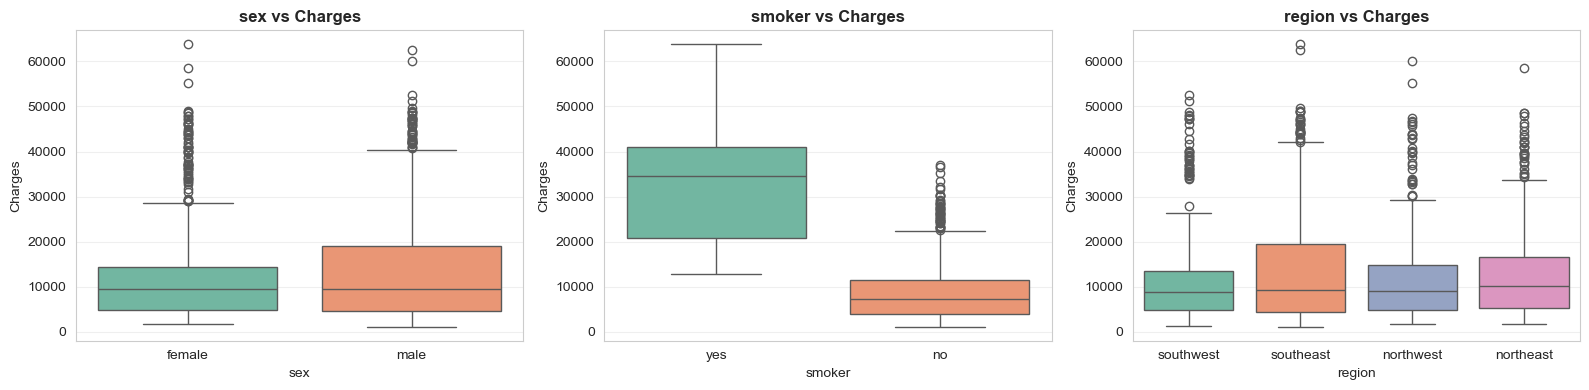


MEAN CHARGES BY CATEGORICAL FEATURES

Mean Charges by sex:
        count          mean           std        min          max
sex                                                              
female    662  12569.578844  11128.703801  1607.5101  63770.42801
male      675  13974.998864  12971.958663  1121.8739  62592.87309

Mean Charges by smoker:
        count          mean           std         min          max
smoker                                                            
no       1063   8440.660307   5992.973800   1121.8739  36910.60803
yes       274  32050.231832  11541.547176  12829.4551  63770.42801

Mean Charges by region:
           count          mean           std        min          max
region                                                              
northeast    324  13406.384516  11255.803066  1694.7964  58571.07448
northwest    324  12450.840844  11073.125699  1621.3402  60021.39897
southeast    364  14735.411438  13971.098589  1121.8739  63770.42801
southwest    

In [15]:
# Categorical Variables Analysis
print("=" * 80)
print("CATEGORICAL VARIABLES DISTRIBUTION")
print("=" * 80)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for idx, col in enumerate(categorical_cols):
    value_counts = df[col].value_counts()
    print(f"\n{col}:")
    print(value_counts)
    print(f"Value Percentages:")
    print(df[col].value_counts(normalize=True) * 100)
    
    # Create bar plots
    value_counts.plot(kind='bar', ax=axes[idx], color=['skyblue', 'lightcoral', 'lightgreen', 'lightyellow'][:len(value_counts)], edgecolor='black')
    axes[idx].set_title(f'Distribution of {col}', fontweight='bold')
    axes[idx].set_ylabel('Count')
    axes[idx].set_xlabel(col)
    axes[idx].tick_params(axis='x', rotation=45)
    
    # Add count labels on bars
    for i, v in enumerate(value_counts.values):
        axes[idx].text(i, v + 5, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Categorical vs Target Variable (Charges)
print("\n" + "=" * 80)
print("CATEGORICAL FEATURES vs TARGET (CHARGES)")
print("=" * 80)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for idx, col in enumerate(categorical_cols):
    # Box plot
    df_temp = df[[col, 'charges']].copy()
    sns.boxplot(data=df_temp, x=col, y='charges', ax=axes[idx], palette='Set2')
    axes[idx].set_title(f'{col} vs Charges', fontweight='bold')
    axes[idx].set_ylabel('Charges')
    axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Statistical analysis by category
print("\n" + "=" * 80)
print("MEAN CHARGES BY CATEGORICAL FEATURES")
print("=" * 80)

for col in categorical_cols:
    print(f"\nMean Charges by {col}:")
    print(df.groupby(col)['charges'].agg(['count', 'mean', 'std', 'min', 'max']))

# Smoker vs Non-smoker analysis
print("\n" + "=" * 80)
print("SMOKER vs NON-SMOKER ANALYSIS")
print("=" * 80)

smoker_stats = df.groupby('smoker')['charges'].describe()
print(smoker_stats)

## 10. Multivariate Analysis - Pairplots and Relationships

PAIRPLOT - MULTIVARIATE RELATIONSHIPS

Generating pairplot (this may take a moment)...


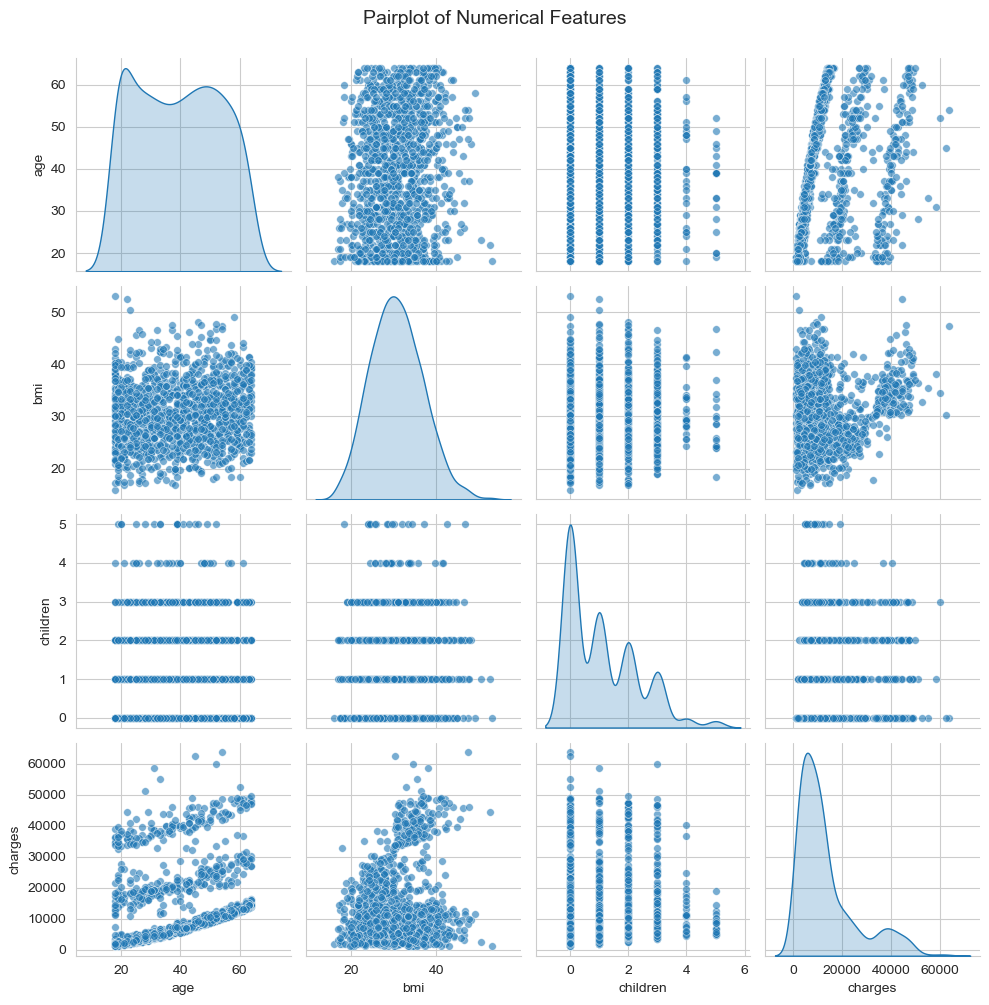


Generating pairplot colored by Smoker status...


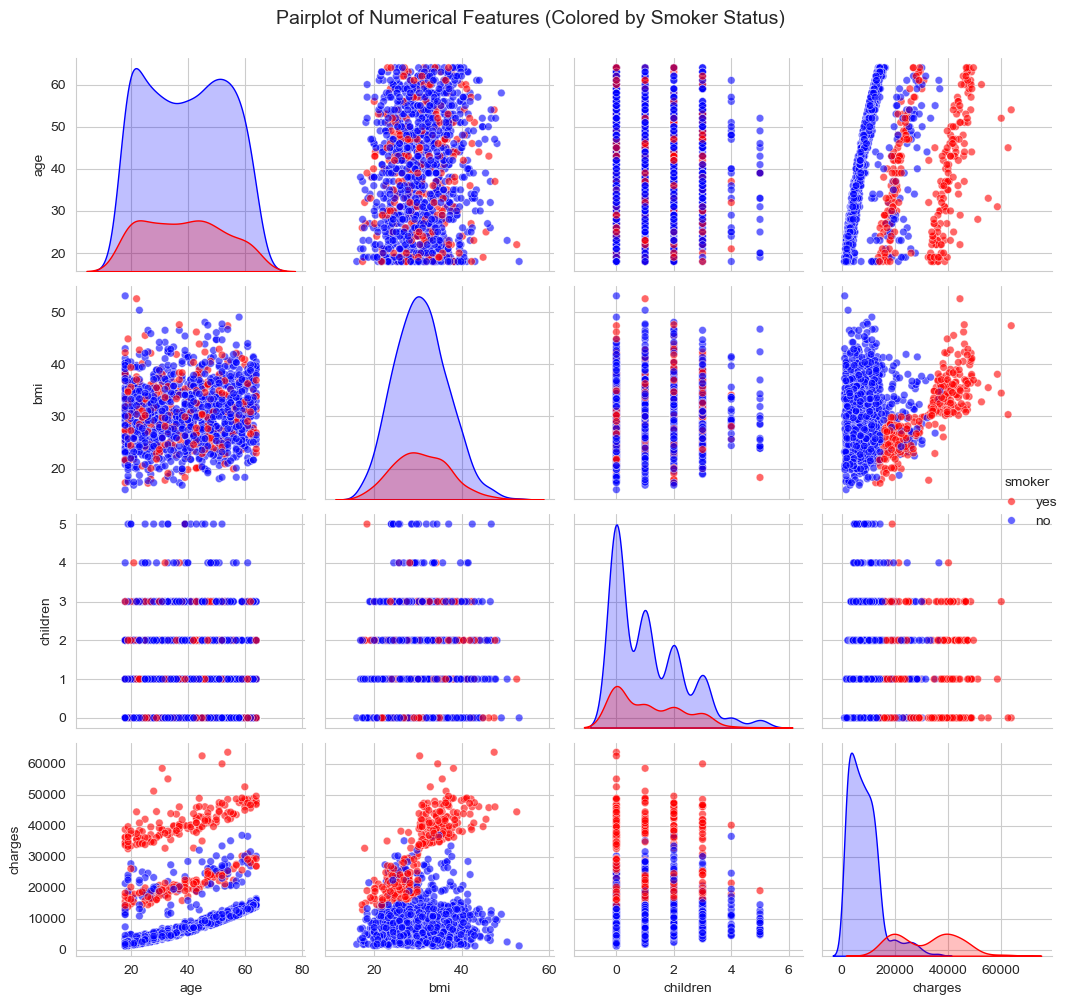

In [16]:
# Pairplot - Relationships among numerical features
print("=" * 80)
print("PAIRPLOT - MULTIVARIATE RELATIONSHIPS")
print("=" * 80)
print("\nGenerating pairplot (this may take a moment)...")

pairplot_df = df[numerical_cols].copy()
pairplot_fig = sns.pairplot(pairplot_df, diag_kind='kde', plot_kws={'alpha': 0.6, 's': 30})
pairplot_fig.fig.suptitle('Pairplot of Numerical Features', fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

# Pairplot with categorical coloring (Smoker)
print("\nGenerating pairplot colored by Smoker status...")

df_categorical = df[numerical_cols + ['smoker']].copy()
pairplot_cat = sns.pairplot(df_categorical, hue='smoker', diag_kind='kde', 
                             palette={'yes': 'red', 'no': 'blue'}, 
                             plot_kws={'alpha': 0.6, 's': 30})
pairplot_cat.fig.suptitle('Pairplot of Numerical Features (Colored by Smoker Status)', 
                          fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

## 11. Advanced Seaborn Visualizations

VIOLIN PLOTS - DISTRIBUTION BY CATEGORY


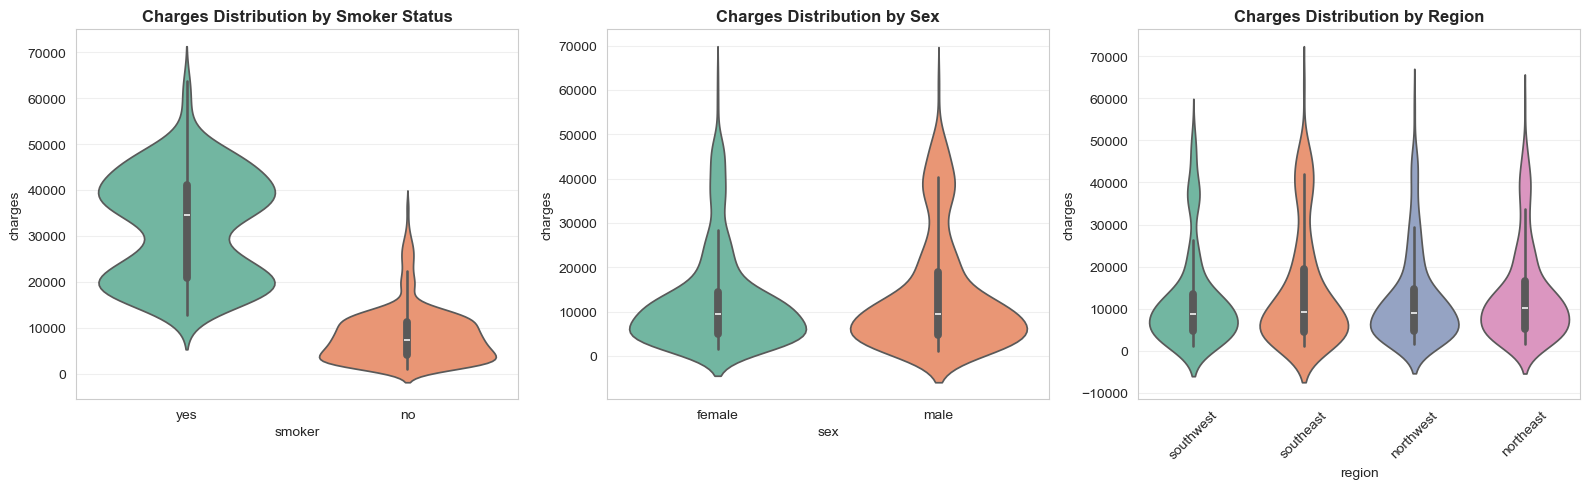


Generating distribution plots with KDE...


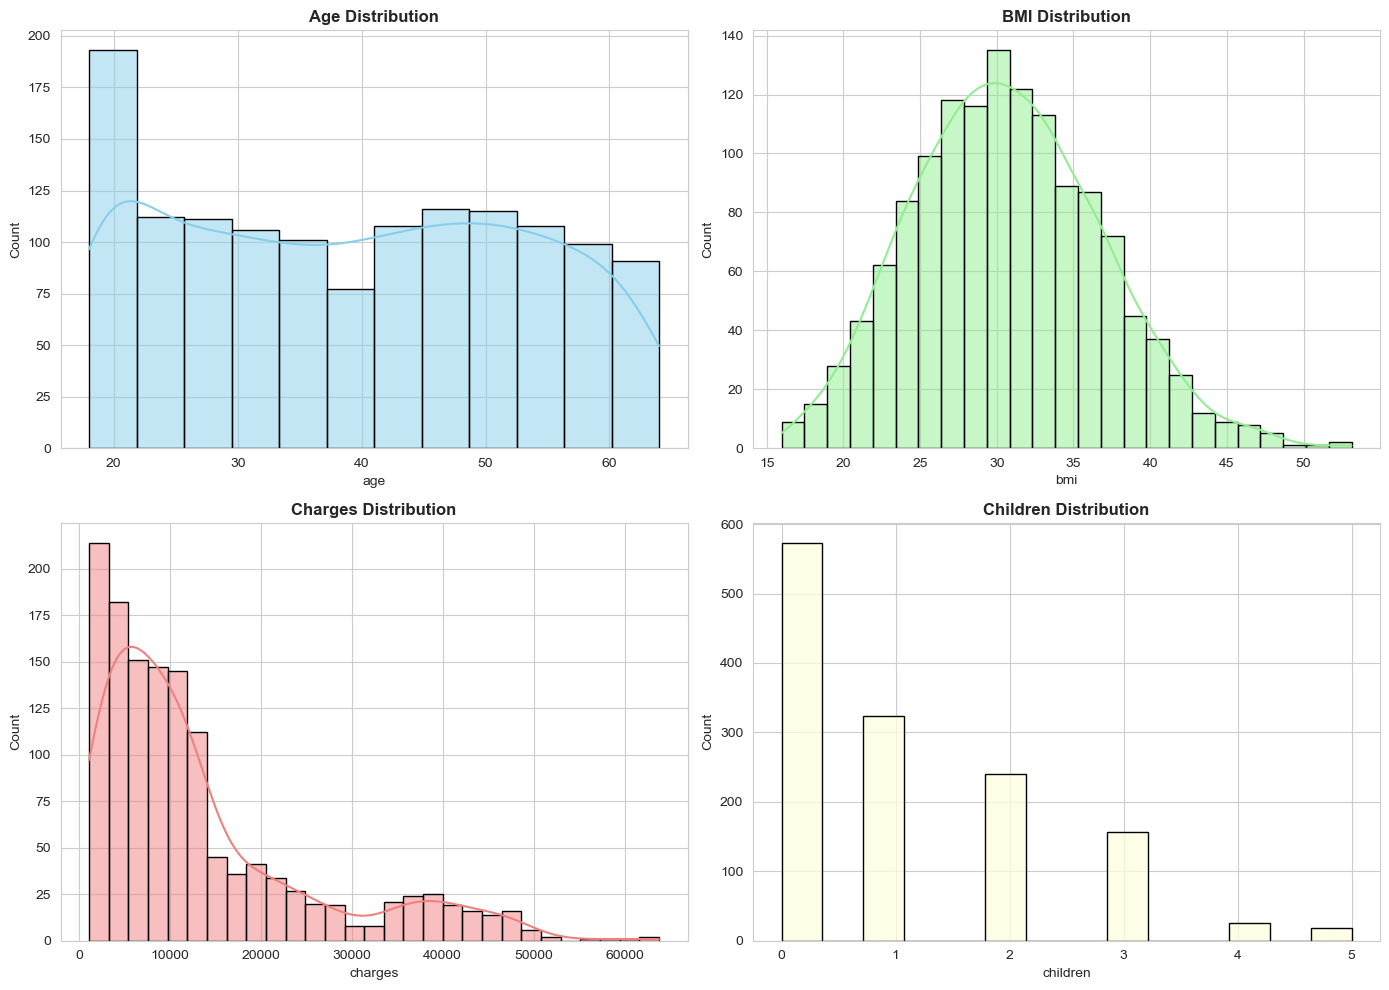


Generating FacetGrid visualizations...


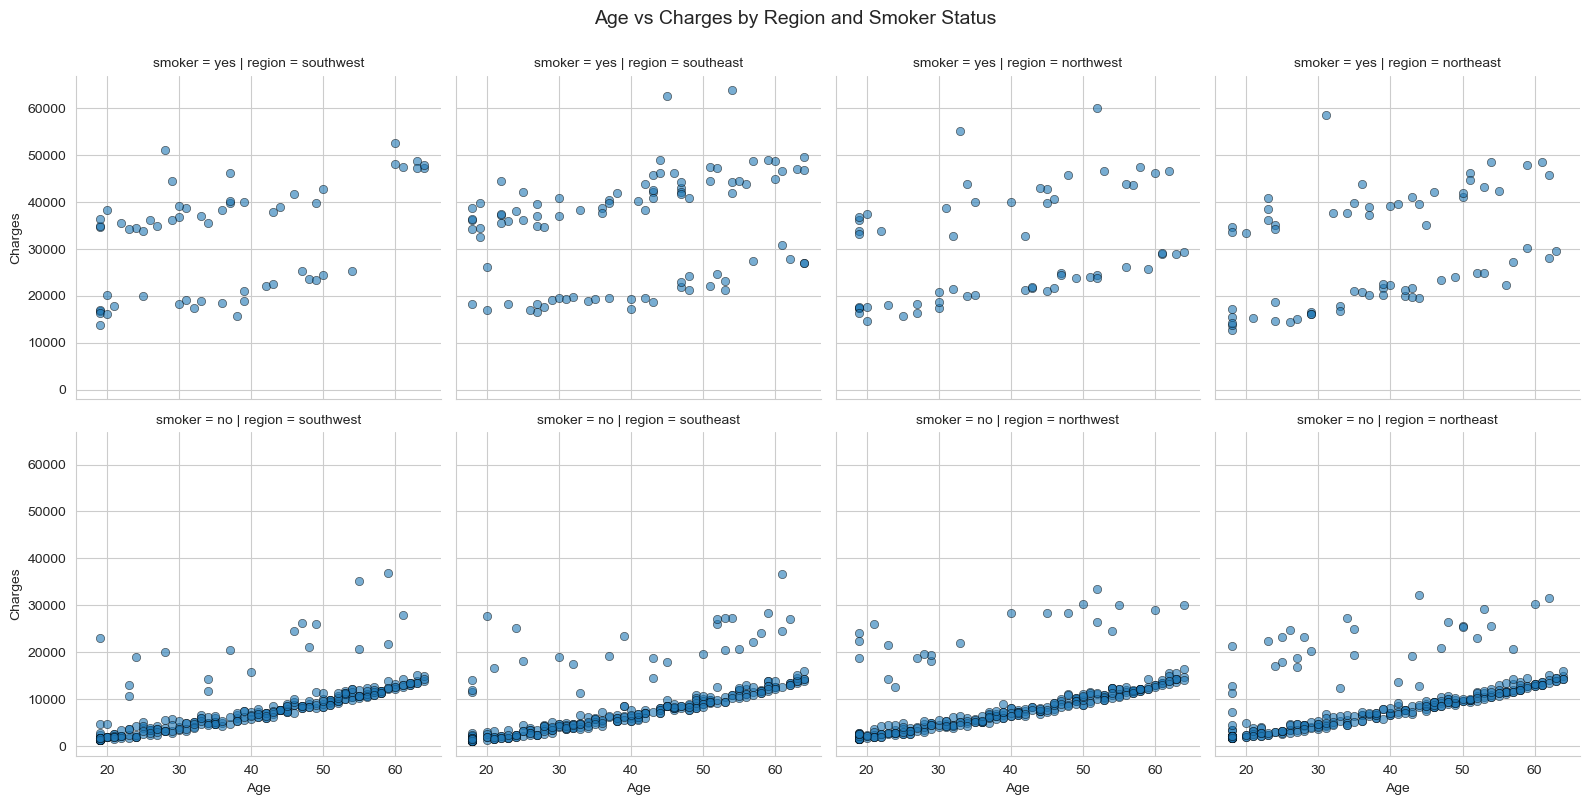

In [17]:
# Violin plots - Distribution comparison by category
print("=" * 80)
print("VIOLIN PLOTS - DISTRIBUTION BY CATEGORY")
print("=" * 80)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Charges by Smoker
sns.violinplot(data=df, x='smoker', y='charges', ax=axes[0], palette='Set2')
axes[0].set_title('Charges Distribution by Smoker Status', fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Charges by Sex
sns.violinplot(data=df, x='sex', y='charges', ax=axes[1], palette='Set2')
axes[1].set_title('Charges Distribution by Sex', fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

# Charges by Region
sns.violinplot(data=df, x='region', y='charges', ax=axes[2], palette='Set2')
axes[2].set_title('Charges Distribution by Region', fontweight='bold')
axes[2].tick_params(axis='x', rotation=45)
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Distribution plots with KDE
print("\nGenerating distribution plots with KDE...")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Age distribution
sns.histplot(data=df, x='age', kde=True, ax=axes[0, 0], color='skyblue', edgecolor='black')
axes[0, 0].set_title('Age Distribution', fontweight='bold')

# BMI distribution
sns.histplot(data=df, x='bmi', kde=True, ax=axes[0, 1], color='lightgreen', edgecolor='black')
axes[0, 1].set_title('BMI Distribution', fontweight='bold')

# Charges distribution
sns.histplot(data=df, x='charges', kde=True, ax=axes[1, 0], color='lightcoral', edgecolor='black')
axes[1, 0].set_title('Charges Distribution', fontweight='bold')

# Children distribution
sns.histplot(data=df, x='children', kde=False, ax=axes[1, 1], color='lightyellow', edgecolor='black')
axes[1, 1].set_title('Children Distribution', fontweight='bold')

plt.tight_layout()
plt.show()

# FacetGrid - Multi-dimensional visualization
print("\nGenerating FacetGrid visualizations...")

# Smoker status across regions
g = sns.FacetGrid(df, col='region', row='smoker', height=4, aspect=1)
g.map(plt.scatter, 'age', 'charges', alpha=0.6, edgecolor='black', linewidth=0.5)
g.set_axis_labels('Age', 'Charges')
plt.suptitle('Age vs Charges by Region and Smoker Status', fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

## 12. Interactive Visualizations with Plotly

In [18]:
# Interactive scatter plot - Age vs Charges with color by Smoker
print("=" * 80)
print("INTERACTIVE PLOTLY VISUALIZATIONS")
print("=" * 80)

fig1 = px.scatter(df, x='age', y='charges', color='smoker', 
                   size='bmi', hover_name='region',
                   title='Interactive: Age vs Charges (Colored by Smoker, Size by BMI)',
                   labels={'charges': 'Insurance Charges ($)', 'age': 'Age (years)'},
                   color_discrete_map={'yes': 'red', 'no': 'blue'})
fig1.update_layout(height=600, hovermode='closest')
fig1.show()

# 3D scatter plot
print("\nGenerating 3D scatter plot...")

fig2 = px.scatter_3d(df, x='age', y='bmi', z='charges', color='smoker',
                     size='children', hover_name='region',
                     title='3D Interactive Plot: Age vs BMI vs Charges',
                     color_discrete_map={'yes': 'red', 'no': 'blue'})
fig2.update_layout(height=700)
fig2.show()

# Box plot - Interactive version
fig3 = px.box(df, x='smoker', y='charges', color='sex', 
             title='Interactive Box Plot: Charges by Smoker and Sex',
             labels={'charges': 'Insurance Charges ($)'},
             color_discrete_map={'male': 'blue', 'female': 'pink'})
fig3.update_layout(height=500)
fig3.show()

# Violin plot - Interactive
fig4 = px.violin(df, x='region', y='charges', color='smoker',
                title='Interactive Violin Plot: Charges by Region and Smoker',
                labels={'charges': 'Insurance Charges ($)'},
                color_discrete_map={'yes': 'red', 'no': 'blue'})
fig4.update_layout(height=500)
fig4.show()

# Histogram with marginal distributions
fig5 = px.histogram(df, x='charges', marginal='box', nbins=30, color='smoker',
                   title='Distribution of Charges with Box Plot (Marginal)',
                   labels={'charges': 'Insurance Charges ($)'},
                   color_discrete_map={'yes': 'red', 'no': 'blue'},
                   opacity=0.7)
fig5.update_layout(height=600)
fig5.show()

# Bubble chart
fig6 = px.scatter(df, x='age', y='bmi', size='charges', color='region',
                 hover_name='smoker', title='Bubble Chart: Age vs BMI (Size=Charges, Color=Region)',
                 labels={'charges': 'Charges ($)'})
fig6.update_layout(height=600)
fig6.show()

INTERACTIVE PLOTLY VISUALIZATIONS



Generating 3D scatter plot...


## 13. Summary of Key Insights and Findings

In [19]:
print("=" * 80)
print("KEY INSIGHTS AND FINDINGS FROM EDA")
print("=" * 80)

print("\n1. DATASET OVERVIEW:")
print(f"   - Total Records: {df.shape[0]}")
print(f"   - Total Features: {df.shape[1]}")
print(f"   - Numerical Features: {len(numerical_cols)}")
print(f"   - Categorical Features: {len(categorical_cols)}")

print("\n2. TARGET VARIABLE (CHARGES):")
print(f"   - Mean Charges: ${df['charges'].mean():.2f}")
print(f"   - Median Charges: ${df['charges'].median():.2f}")
print(f"   - Std Dev: ${df['charges'].std():.2f}")
print(f"   - Range: ${df['charges'].min():.2f} - ${df['charges'].max():.2f}")

print("\n3. KEY CORRELATIONS WITH CHARGES:")
correlations = df[numerical_cols].corr()['charges'].sort_values(ascending=False)
for var, corr in correlations.items():
    if var != 'charges':
        print(f"   - {var}: {corr:.3f}")

print("\n4. SMOKER STATUS IMPACT:")
smoker_mean = df[df['smoker'] == 'yes']['charges'].mean()
non_smoker_mean = df[df['smoker'] == 'no']['charges'].mean()
print(f"   - Average Charges (Smokers): ${smoker_mean:.2f}")
print(f"   - Average Charges (Non-smokers): ${non_smoker_mean:.2f}")
print(f"   - Difference: ${smoker_mean - non_smoker_mean:.2f}")
print(f"   - Smokers pay {((smoker_mean/non_smoker_mean - 1) * 100):.1f}% more")

print("\n5. AGE SEGMENT ANALYSIS:")
age_segments = pd.cut(df['age'], bins=[0, 30, 50, 70], labels=['Young (18-30)', 'Middle (31-50)', 'Senior (51+)'])
print("   Mean Charges by Age Group:")
print(df.groupby(age_segments)['charges'].agg(['count', 'mean', 'min', 'max']))

print("\n6. REGION WISDOM:")
print("   Average Charges by Region:")
print(df.groupby('region')['charges'].agg(['count', 'mean', 'std']).sort_values('mean', ascending=False))

print("\n7. BMI IMPACT:")
print(f"   - Average BMI: {df['bmi'].mean():.2f}")
print(f"   - BMI Correlation with Charges: {df['bmi'].corr(df['charges']):.3f}")
print("   - Charges by BMI Category:")
bmi_categories = pd.cut(df['bmi'], bins=[0, 18.5, 25, 30, 100], 
                         labels=['Underweight', 'Normal', 'Overweight', 'Obese'])
print(df.groupby(bmi_categories)['charges'].describe())

print("\n8. CHILDREN IMPACT:")
print("   Average Charges by Number of Children:")
print(df.groupby('children')['charges'].agg(['count', 'mean']))

print("\n9. GENDER ANALYSIS:")
print("   Average Charges by Sex:")
print(df.groupby('sex')['charges'].agg(['count', 'mean', 'std']))

print("\n10. DATA QUALITY:")
print(f"   - Missing Values: {df.isnull().sum().sum()}")
print(f"   - Duplicate Rows: {df.duplicated().sum()}")
print(f"   - Data Types Validated: ✓")

print("\n" + "=" * 80)
print("EDA ANALYSIS COMPLETE!")
print("=" * 80)

KEY INSIGHTS AND FINDINGS FROM EDA

1. DATASET OVERVIEW:
   - Total Records: 1337
   - Total Features: 7
   - Numerical Features: 4
   - Categorical Features: 3

2. TARGET VARIABLE (CHARGES):
   - Mean Charges: $13279.12
   - Median Charges: $9386.16
   - Std Dev: $12110.36
   - Range: $1121.87 - $63770.43

3. KEY CORRELATIONS WITH CHARGES:
   - age: 0.298
   - bmi: 0.198
   - children: 0.067

4. SMOKER STATUS IMPACT:
   - Average Charges (Smokers): $32050.23
   - Average Charges (Non-smokers): $8440.66
   - Difference: $23609.57
   - Smokers pay 279.7% more

5. AGE SEGMENT ANALYSIS:
   Mean Charges by Age Group:
                count          mean        min          max
age                                                        
Young (18-30)     443   9415.064442  1121.8739  51194.55914
Middle (31-50)    538  13280.774031  3260.1990  62592.87309
Senior (51+)      356  18084.987223  8782.4690  63770.42801

6. REGION WISDOM:
   Average Charges by Region:
           count          mean